Demo notebook for ptycho

Arthur McCray  
Last remembered to update this line: 8/25/25

In [1]:
%load_ext autoreload
%autoreload 2 

In [2]:
from pathlib import Path

import numpy as np
import quantem as em
import torch
from quantem.core import config
from quantem.core.datastructures import Dataset4dstem
from quantem.core.ml.cnn2d import CNN2d
from quantem.core.utils.utils import electron_wavelength_angstrom
from quantem.core.visualization import show_2d
from quantem.diffractive_imaging.dataset_models import PtychographyDatasetRaster
from quantem.diffractive_imaging.detector_models import DetectorPixelated
from quantem.diffractive_imaging.object_models import ObjectDIP, ObjectPixelated
from quantem.diffractive_imaging.probe_models import ProbeDIP, ProbePixelated
from quantem.diffractive_imaging.ptychography import Ptychography


GPU_ID = 1
config.set_device(GPU_ID)
print(f"Using GPU {config.get('device')}")


Using GPU cuda:1


# Ducky

In [3]:
_f = Path("/data/shared/resources/example_data/ducky_251105_20mrad_500A-df_4A-step_5e+04-dose_clean.zip")
dset: Dataset4dstem = em.io.load(_f)

In [4]:
PROBE_ENERGY = 80e3 # eV
PROBE_SEMIANGLE = 20 # mrad
PROBE_DEFOCUS = 500 # A 

Dataset(shape=(37, 37, 96, 96), dtype=float32, name='4D-STEM dataset(slice(None, None, None), slice(None, None, None), slice(52, -52, None), slice(52, -52, None))')
  sampling: [4.    4.    0.025 0.025]
  units: ['A', 'A', 'A^-1', 'A^-1']
  signal units: 'arb. units'

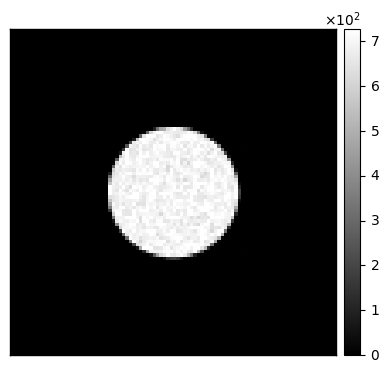

In [ ]:
dset_crop = dset[:,:,52:-52,52:-52]
show_2d(dset_crop[0,0].array, cbar=True)
dset_crop

Calculated best fit rotation = 0 degrees.


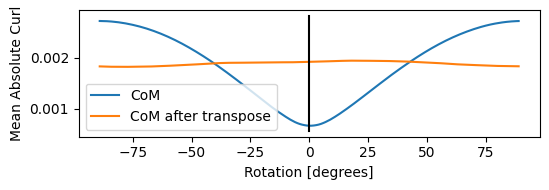

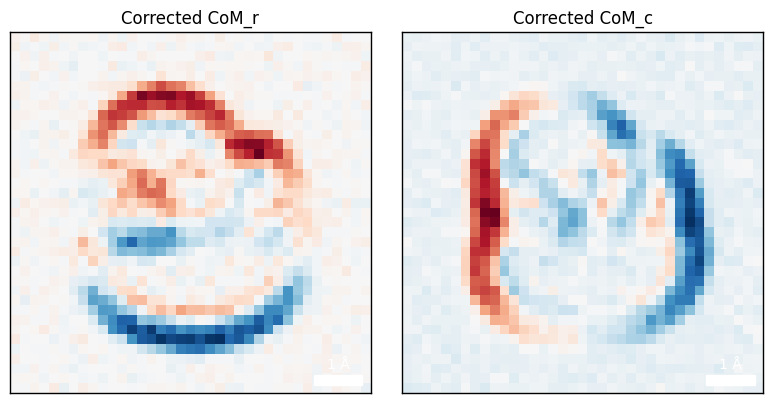

Normalizing intensities:   0%|          | 0/1369 [00:00<?, ?probe position/s]

In [6]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)
pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=True,
    plot_com=True,
)

## pixelated
- tensorboard logging is optional 

In [7]:
from quantem.diffractive_imaging.logger_ptychography import LoggerPtychography

logger = None
# logger = LoggerPtychography(
#     # log_dir = "../logs/",
#     log_dir = data_dir / "logs",
#     run_prefix=dset.name,
#     run_suffix="",
#     log_images_every=10,
#     log_probe_images=False,
# )

In [69]:
obj_model_pix = ObjectPixelated.from_uniform(
    obj_type="pure_phase",
)

probe_params = {
    "energy": PROBE_ENERGY,
    "defocus": PROBE_DEFOCUS,
    "semiangle_cutoff": PROBE_SEMIANGLE,
}

probe_model_pix = ProbePixelated.from_params(
    num_probes=1,
    probe_params=probe_params,
)

detector_model = DetectorPixelated()

ptycho_pix = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    logger=logger,
    rng=42, 
)

ptycho_pix.preprocess(
    obj_padding_px=(32, 32),
)

  0%|          | 0/50 [00:00<?, ?it/s]

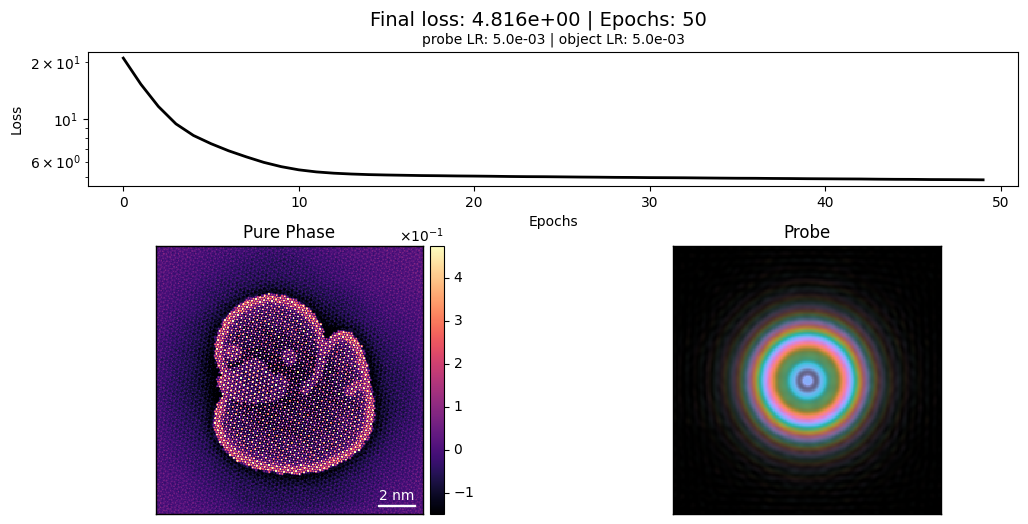

In [70]:
opt_params = {
    "object": {
        "type": "adam",
        "lr": 5e-3,
    },
    "probe": {
        "type": "adam",
        "lr": 5e-3,
    },
}


ptycho_pix.reconstruct(
    num_iter=50,
    reset=True,
    device="gpu",
    optimizer_params=opt_params,
    batch_size=125,
).visualize()

In [ ]:
oc = ptycho_pix.obj_cropped.sum(0)
if ptycho_pix.obj_model.obj_type == "complex":
    oc = np.angle(oc)
show_2d(
    [oc, oc[:80, :80]],
    cmap=["turbo", "magma"],
    title = [
        f"pixelated {ptycho_pix.obj_model.obj_type} | {ptycho_pix.num_epochs} epochs",
        "zoom",
    ]
)
show_2d(
    [
        oc,
        oc[:80, :80],
        oc[100:180, 100:180],
    ],
    cmap="magma",
    title=[
        f"pixelated {ptycho_pix.obj_model.obj_type} | {ptycho_pix.num_epochs} epochs",
        "zoom",
        "zoom",
    ],
)

  0%|          | 0/150 [00:00<?, ?it/s]

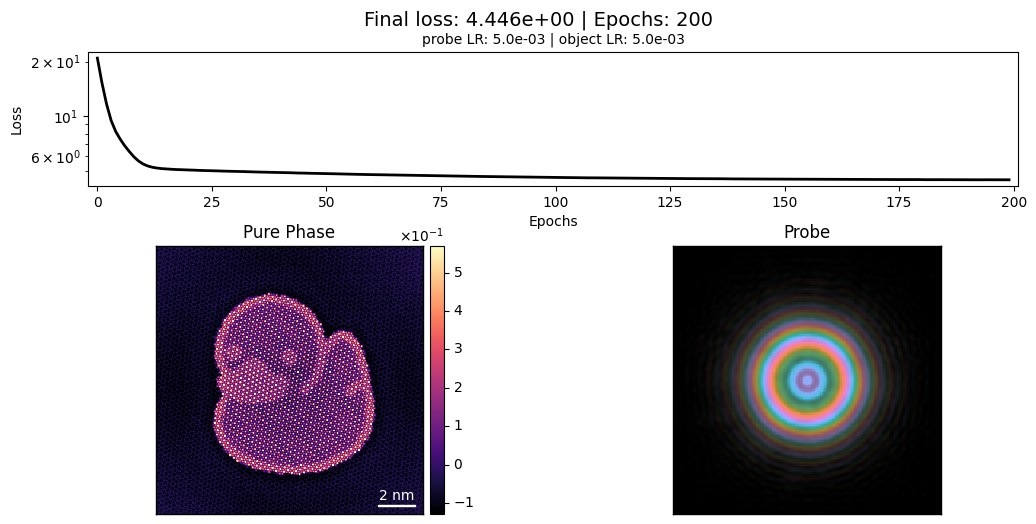

In [72]:
ptycho_pix.reconstruct(
    num_iter=150,
).visualize()


In [ ]:
oc = ptycho_pix.obj_cropped.sum(0)
if ptycho_pix.obj_model.obj_type == "complex":
    oc = np.angle(oc)
show_2d(
    [oc, oc[:80, :80]],
    cmap=["turbo", "magma"],
    title = [
        f"pixelated {ptycho_pix.obj_model.obj_type} | {ptycho_pix.num_epochs} epochs",
        "zoom",
    ]
)
show_2d(
    [
        oc,
        oc[:80, :80],
        oc[100:180, 100:180],
    ],
    cmap="magma",
    title=[
        f"pixelated {ptycho_pix.obj_model.obj_type} | {ptycho_pix.num_epochs} epochs",
        "zoom",
        "zoom",
    ],
)

## DIP

  0%|          | 0/50 [00:00<?, ?it/s]

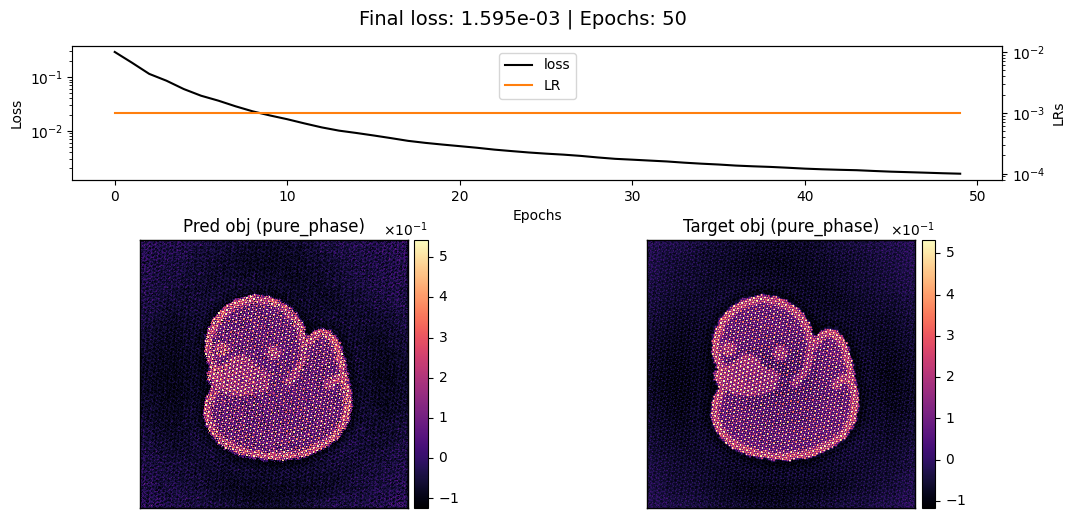

  0%|          | 0/50 [00:00<?, ?it/s]

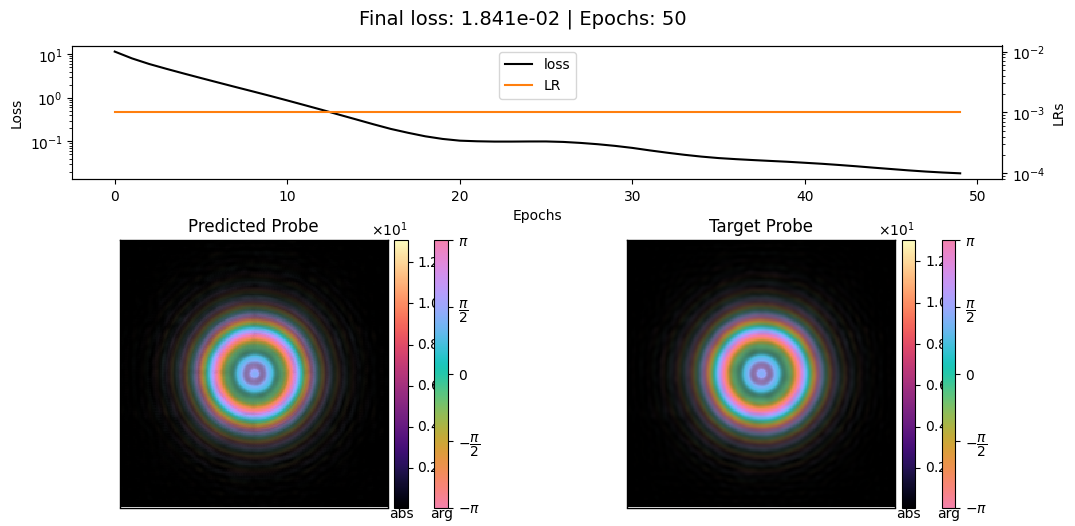

In [74]:
model_dip = CNN2d(
    in_channels=1,
    use_skip_connections=True,
    dtype=torch.complex64 if ptycho_pix.obj_model.obj_type == "complex" else torch.float32,
    final_activation="softplus" if ptycho_pix.obj_model.obj_type == "potential" else "identity",
)
obj_model_dip = ObjectDIP.from_pixelated(
    model=model_dip,
    pixelated=obj_model_pix,
)

probe_dip = CNN2d(
    in_channels=1,
    use_skip_connections=True,
    dtype = torch.complex64,
)
probe_model_dip = ProbeDIP.from_pixelated(
    model=probe_dip,
    pixelated=probe_model_pix,
)

obj_model_dip.pretrain(
    num_epochs=50,
    optimizer_params={
        "type": torch.optim.Adam,
        "lr": 1e-3,
    },
    scheduler_params={
        "type": "plateau",
        "factor": 0.5,
    },
    device=config.get("device"),
)

probe_model_dip.pretrain(
    num_epochs=50,
    optimizer_params={
        "type": torch.optim.Adam,
        "lr": 1e-3,
    },
    scheduler_params={
        "type": "plateau",
        "factor": 0.5,
    },
    device=config.get("device"),
)

ptycho_dip = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_dip,
    probe_model=probe_model_dip,
    detector_model=detector_model,
    device=config.get("device"),
    logger=logger,
)

ptycho_dip.preprocess(
    obj_padding_px=(32, 32),
)

  0%|          | 0/25 [00:00<?, ?it/s]

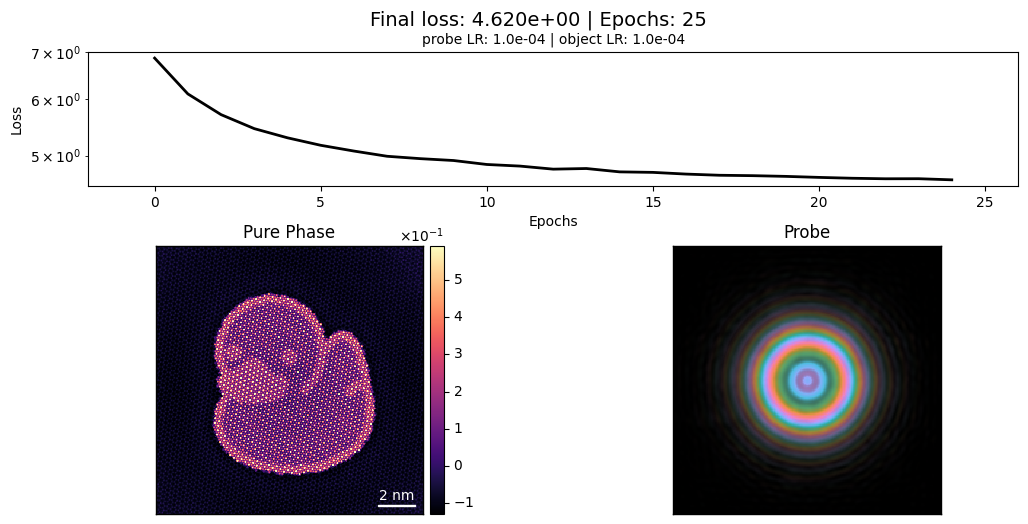

In [75]:
opt_params = {  
    "object": {
        "type": "adam",  
        "lr": 1e-4,
    },
    "probe": {
        "type": "adam",
        "lr": 1e-4,
    },
}

scheduler_params = {
    "object": {
        "type": "plateau",
    },
    "probe": {
        "type": "plateau",
    },
}
ptycho_dip.reconstruct(
    num_iter=25,
    reset=True,
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    batch_size=128,
    device='gpu',
).visualize()

In [ ]:
oc = ptycho_dip.obj_cropped.sum(0)
if ptycho_dip.obj_model.obj_type == "complex":
    oc = np.angle(oc)
show_2d(
    [oc, oc[:80, :80]],
    cmap=["turbo", "magma"],
    title = [
        f"DIP {ptycho_dip.obj_model.obj_type} | {ptycho_dip.num_epochs} epochs",
        "zoom",
    ]
)
show_2d(
    [
        oc,
        oc[:80, :80],
        oc[100:180, 100:180],
    ],
    cmap="magma",
    title=[
        f"DIP {ptycho_dip.obj_model.obj_type} | {ptycho_dip.num_epochs} epochs",
        "zoom",
        "zoom",
    ],
)

  0%|          | 0/75 [00:00<?, ?it/s]

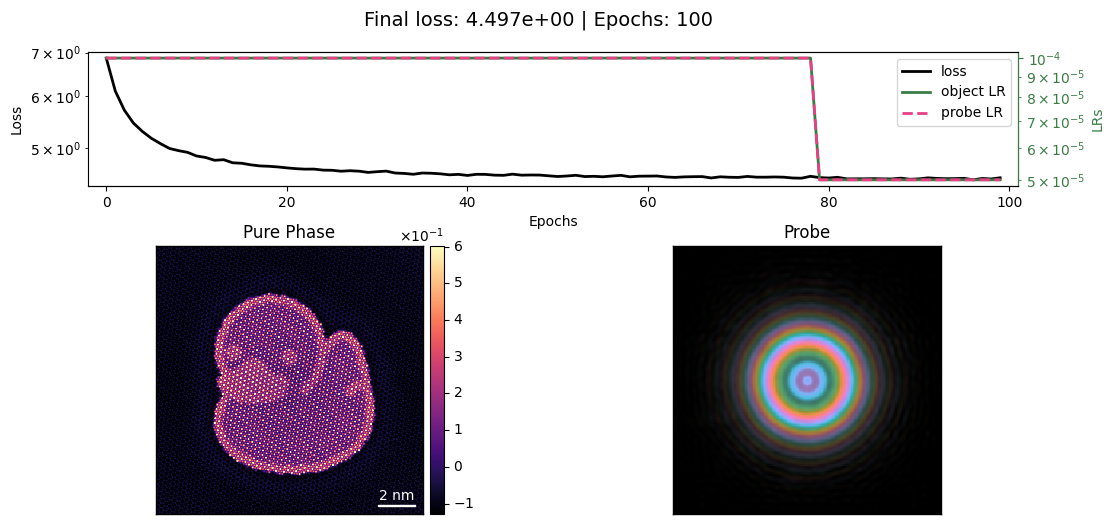

In [77]:
ptycho_dip.reconstruct(
    num_iter=75,
).visualize()

In [ ]:
oc = ptycho_dip.obj_cropped.sum(0)
if ptycho_dip.obj_model.obj_type == "complex":
    oc = np.angle(oc)
show_2d(
    [oc, oc[20:180, 20:180]],
    cmap=["turbo", "magma"],
    title = [
        f"DIP {ptycho_dip.obj_model.obj_type} | {ptycho_dip.num_epochs} epochs",
        "zoom",
    ]
)
show_2d(
    [
        oc,
        oc[20:180, 20:180],
        oc[100:180, 100:180],
    ],
    cmap="magma",
    title=[
        f"DIP {ptycho_dip.obj_model.obj_type} | {ptycho_dip.num_epochs} epochs",
        "zoom",
        "zoom",
    ],
)

## save/load

In [17]:
ptycho_dip.save("../data/ptycho_dip.zip", mode='o')

Saving ptychography object to ../data/ptycho_dip.zip


In [18]:
ptycho_dip2 = Ptychography.from_file("../data/ptycho_dip.zip",dset=pdset)

Epoch 10/10, Loss: 1.462e+00: 100%|██████████| 10/10 [00:03<00:00,  2.74it/s]


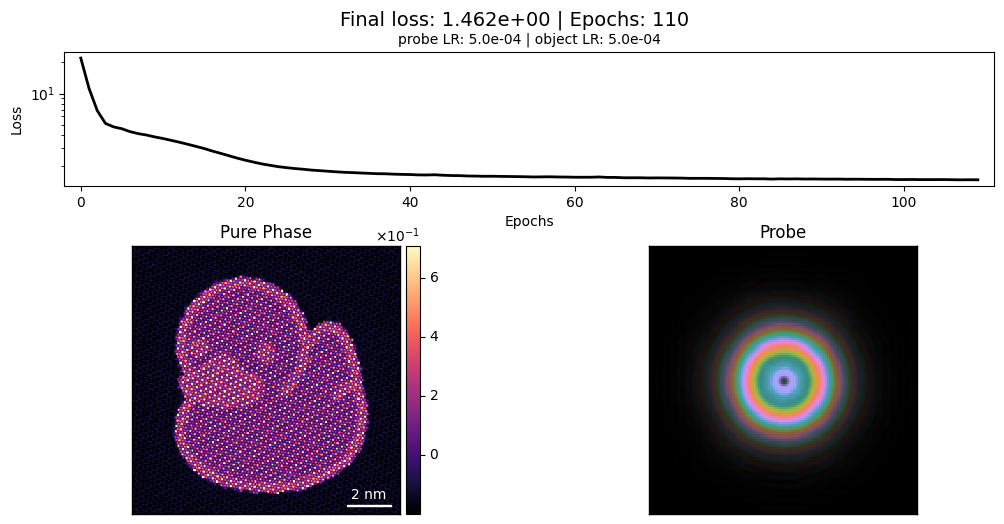

In [19]:
ptycho_dip2.reconstruct(
    num_iter=10,
    device='gpu',
).visualize()

In [ ]:
ph = ptycho_dip2.obj_cropped[0]
if ptycho_dip2.obj_model.obj_type == "complex":
    ph = np.angle(ph)
show_2d(
    [ph, ph[:80, :80]],
    cmap=["turbo", "magma"],
    title=[f"DIP {ptycho_dip2.obj_model.obj_type} | {ptycho_dip2.num_epochs} epochs", f"DIP {ptycho_dip2.num_epochs} epochs zoom"]
)
show_2d(
    [
        ph,
        ph[:80, :80],
        ph[100:180, 100:180],
    ],
    cmap="magma",
    title=[f"DIP {ptycho_dip2.obj_model.obj_type} | {ptycho_dip2.num_epochs} epochs", "DIP zoom", "DIP zoom"],
)

# White noise

In [21]:
# parameters
N = 64
Q_MAX = 0.5 # inverse Angstroms
q_probe = Q_MAX/2 # inverse Angstroms
PROBE_ENERGY = 300e3 # eV
wavelength = electron_wavelength_angstrom(PROBE_ENERGY) 
sampling = 1 / Q_MAX / 2 # Angstroms
reciprocal_sampling = 2 * Q_MAX / N # inverse Angstroms, set so that no upsampling

SCAN_STEP_SIZE = 1 # pixels
sx = sy = N//SCAN_STEP_SIZE
phi0 = 1
C10 = 50

In [22]:
def white_noise_object_2D(n, phi0):
    """ creates a 2D real-valued array, whose FFT has random phase and constant amplitude """

    evenQ = n%2 == 0
    
    # indices
    pos_ind = np.arange(1,(n if evenQ else n+1)//2)
    neg_ind = np.flip(np.arange(n//2+1,n))

    # random phase
    arr = np.random.randn(n,n)
    
    # top-left // bottom-right
    arr[pos_ind[:,None],pos_ind[None,:]] = -arr[neg_ind[:,None],neg_ind[None,:]]
    # bottom-left // top-right
    arr[pos_ind[:,None],neg_ind[None,:]] = -arr[neg_ind[:,None],pos_ind[None,:]]
    # kx=0
    arr[0,pos_ind] = -arr[0,neg_ind]
    # ky=0
    arr[pos_ind,0] = -arr[neg_ind,0]

    # zero-out components which don't have k-> -k mapping
    if evenQ:
        arr[n//2,:] = 0 # zero highest spatial freq
        arr[:,n//2] = 0 # zero highest spatial freq

    arr[0,0] = 0 # DC component

    # fourier-array
    arr = np.exp(2j*np.pi*arr)*phi0

    # inverse FFT and remove floating point errors
    arr = np.fft.ifft2(arr).real
    
    return arr

# potential
potential = white_noise_object_2D(N,phi0)
complex_obj = np.exp(1j*potential)

In [23]:
qx = qy = np.fft.fftfreq(N,sampling)
q2 = qx[:,None]**2 + qy[None,:]**2
q  = np.sqrt(q2)

aperture_fourier = np.sqrt(
    np.clip(
        (q_probe - q)/reciprocal_sampling + 0.5,
        0,
        1,
    ),
)

chi = q**2 * wavelength * np.pi * C10
exp_chi = np.exp(-1j*chi)
probe_array_fourier = aperture_fourier * exp_chi
probe_array_fourier /= np.sqrt(np.sum(np.abs(probe_array_fourier)**2))
probe_array = np.fft.ifft2(probe_array_fourier) * N

In [24]:
def return_patch_indices(positions_px,roi_shape,obj_shape):
    """ """
    x0 = np.round(positions_px[:, 0]).astype("int")
    y0 = np.round(positions_px[:, 1]).astype("int")

    x_ind = np.fft.fftfreq(roi_shape[0], d=1 / roi_shape[0]).astype("int")
    y_ind = np.fft.fftfreq(roi_shape[1], d=1 / roi_shape[1]).astype("int")

    row = (x0[:, None, None] + x_ind[None, :, None]) % obj_shape[0]
    col = (y0[:, None, None] + y_ind[None, None, :]) % obj_shape[1]

    return row, col

In [25]:
def simulate_exit_waves(
    complex_obj,
    probe,
    row,
    col,
):
    """ """
    obj_patches = complex_obj[row,col]
    exit_waves = obj_patches * probe
    return obj_patches, exit_waves

def simulate_intensities(
    complex_obj,
    probe,
    row,
    col,
):
    """ """
    obj_patches, exit_waves = simulate_exit_waves(
        complex_obj,
        probe,
        row,
        col
    )
    fourier_exit_waves = np.fft.fft2(exit_waves)
    intensities = np.abs(fourier_exit_waves)**2
    return obj_patches, exit_waves, fourier_exit_waves, intensities

x = y = np.arange(0.,N,SCAN_STEP_SIZE)
xx, yy = np.meshgrid(x,y,indexing='ij')
positions = np.stack((xx.ravel(),yy.ravel()),axis=-1)

sim_row, sim_col = return_patch_indices(positions,(N,N),(N,N))

obj_patches, exit_waves, fourier_exit_waves, intensities = simulate_intensities(
    complex_obj,
    probe_array,
    sim_row,
    sim_col
)

In [26]:
dset = Dataset4dstem.from_array( 
    array = np.fft.fftshift(intensities, axes=(-2,-1)).reshape((sx, sy, N, N)),
    sampling = (SCAN_STEP_SIZE, SCAN_STEP_SIZE, reciprocal_sampling, reciprocal_sampling),
    units=("A", "A", "A^-1", "A^-1"),
)

## ptycho

In [27]:
pdset = PtychographyDatasetRaster.from_dataset4dstem(dset)

pdset.preprocess(
    com_fit_function="constant",
    plot_rotation=False,
    plot_com=False,
    probe_energy = PROBE_ENERGY,
    force_com_rotation=0, 
    force_com_transpose=False, 
)

Forcing best fit rotation to 0 degrees.
Forcing transpose of intensities to False.


Normalizing intensities: 100%|██████████| 4096/4096 [00:01<00:00, 2624.43probe position/s]


In [28]:
obj_model_pix = ObjectPixelated.from_uniform(
    num_slices=1,
    obj_type='complex',
    slice_thicknesses=10
)

probe_params = {
    "energy" : PROBE_ENERGY,
    "C10" : C10,
    "semiangle_cutoff" : wavelength*1e3, 
}

probe_model_pix = ProbePixelated.from_array(
    num_probes=1,
    probe_array = probe_array, 
)

detector_model = DetectorPixelated() 


ptycho_pix = Ptychography.from_models(
    dset=pdset,
    obj_model=obj_model_pix,
    probe_model=probe_model_pix,
    detector_model=detector_model,
    rng = 42, 
)

ptycho_pix.preprocess( 
    obj_padding_px=(0,0),
);

Epoch 50/50, Loss: 9.373e-06: 100%|██████████| 50/50 [00:01<00:00, 49.99it/s]


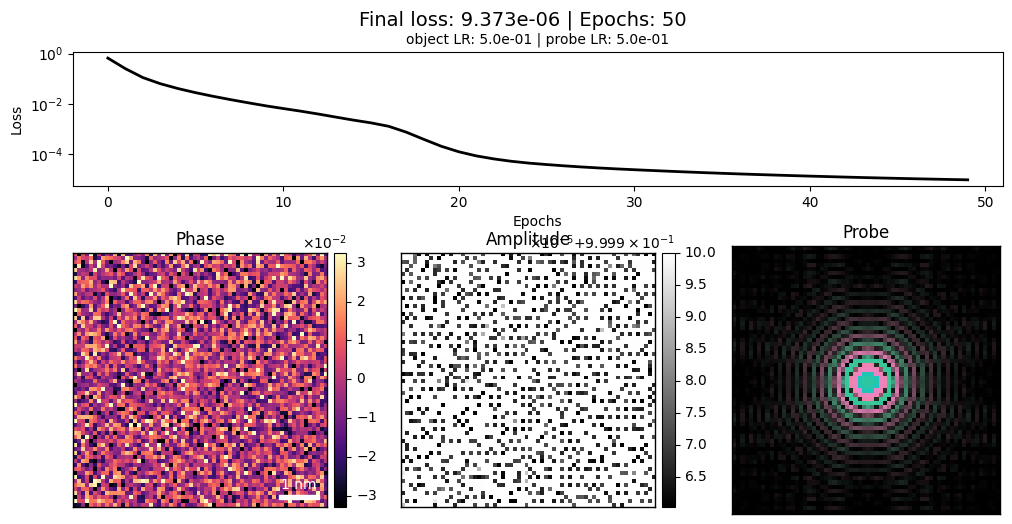

(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': 'SGD optimizers autograd False'}>)

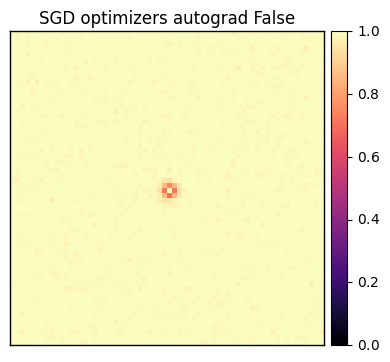

In [29]:
opt_params = { 
        "object": {
            "type": torch.optim.SGD, 
            "lr": 0.5, 
        },
        "probe": {
            "type": "sgd", 
            "lr": 0.5, 
        },
}

scheduler_params = {
}

ptycho_pix.reconstruct(
    num_iter=50,
    reset=True,
    autograd=False, 
    device='gpu',
    optimizer_params=opt_params,
    scheduler_params=scheduler_params,
    batch_size= N**2 // 8,
).visualize()

show_2d(
    np.fft.fftshift(
        np.abs(
            np.fft.fft2(
                ptycho_pix.obj.sum(0)
            )
        )
    ),
    cbar=True, 
    cmap='magma', 
    vmin=0, vmax=1,
    title="SGD optimizers autograd False"
)

Epoch 50/50, Loss: 1.440e-06: 100%|██████████| 50/50 [00:01<00:00, 25.94it/s]


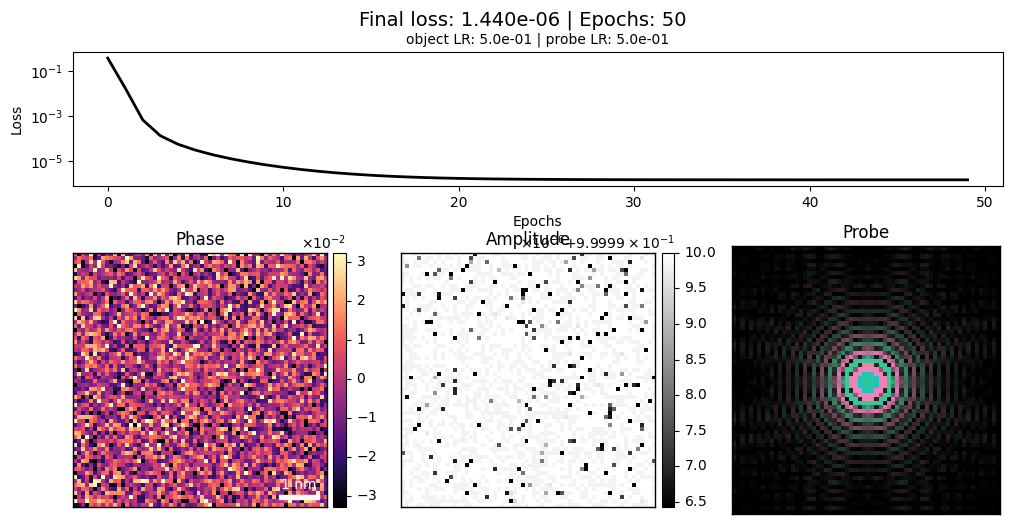

(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': 'SGD optimizers autograd True'}>)

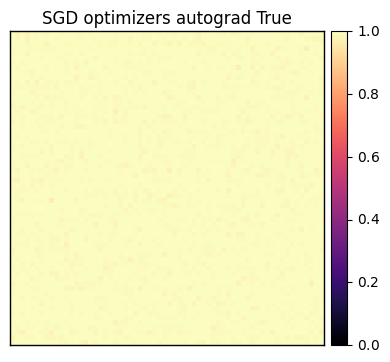

In [30]:
opt_params = { 
        "object": {
            "type": torch.optim.SGD, 
            "lr": 0.5, 
        },
        "probe": {
            "type": "sgd", 
            "lr": 0.5, 
        },
}

ptycho_pix.reconstruct(
    num_iter=50,
    reset=True,
    autograd=True, 
    optimizer_params=opt_params,
).visualize()

show_2d(
    np.fft.fftshift(
        np.abs(
            np.fft.fft2(
                ptycho_pix.obj.sum(0)
            )
        )
    ),
    cbar=True, 
    cmap='magma', 
    vmin=0, vmax=1,
    title="SGD optimizers autograd True"
)

Epoch 50/50, Loss: 2.094e-06: 100%|██████████| 50/50 [00:01<00:00, 45.96it/s]


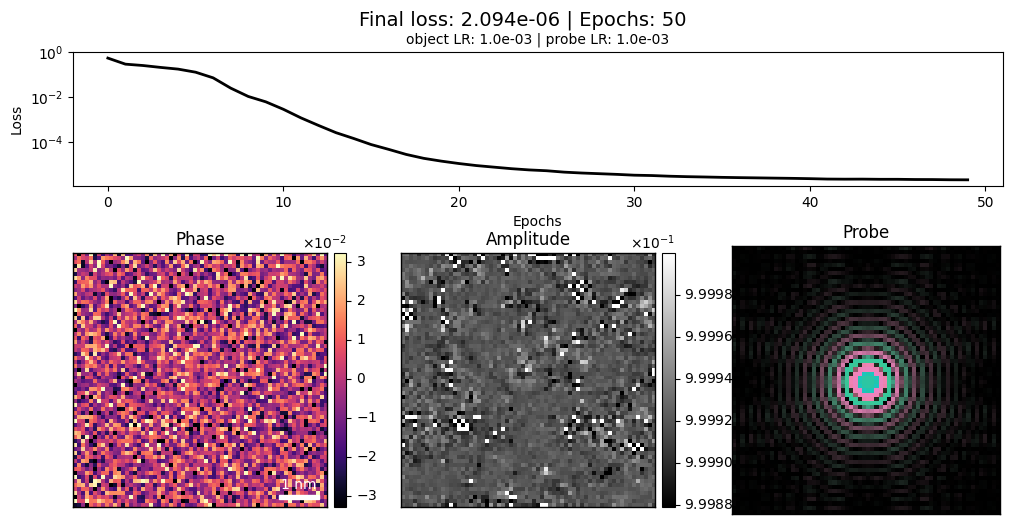

(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': 'Adam optimizers autograd False'}>)

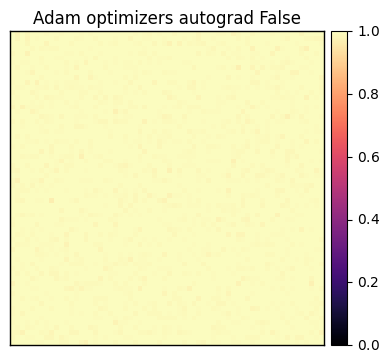

In [31]:
opt_params = { 
        "object": {
            "type": "adam", 
            "lr": 1e-3, 
        },
        "probe": {
            "type": "adam", 
            "lr": 1e-3, 
        },
}

ptycho_pix.reconstruct(
    num_iter=50,
    reset=True,
    autograd=False, 
    optimizer_params=opt_params,
    batch_size= N**2 // 8,
).visualize()

show_2d(
    np.fft.fftshift(
        np.abs(
            np.fft.fft2(
                ptycho_pix.obj.sum(0)
            )
        )
    ),
    cbar=True, 
    cmap='magma', 
    vmin=0, vmax=1,
    title="Adam optimizers autograd False"
)

Epoch 50/50, Loss: 1.567e-06: 100%|██████████| 50/50 [00:03<00:00, 15.79it/s]


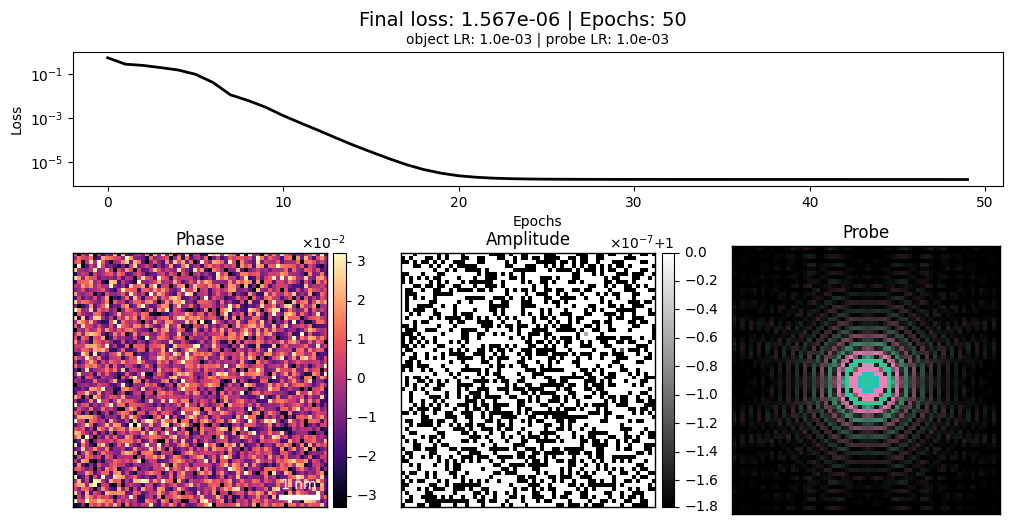

(<Figure size 400x400 with 2 Axes>,
 <Axes: title={'center': 'Adam optimizers autograd True'}>)

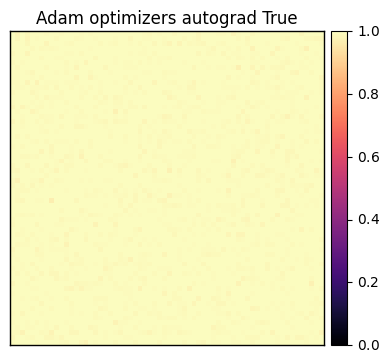

In [32]:
opt_params = { 
        "object": {
            "type": "adam", 
            "lr": 1e-3, 
        },
        "probe": {
            "type": "adam", 
            "lr": 1e-3, 
        },
}

ptycho_pix.reconstruct(
    num_iter=50,
    reset=True,
    autograd=True, 
    optimizer_params=opt_params,
    batch_size= N**2 // 8,
).visualize()

show_2d(
    np.fft.fftshift(
        np.abs(
            np.fft.fft2(
                ptycho_pix.obj.sum(0)
            )
        )
    ),
    cbar=True, 
    cmap='magma', 
    vmin=0, vmax=1,
    title="Adam optimizers autograd True"
)